# 9.1. EEG-fMRI Fusion: Joint Feature Analysis

**Learning Objectives:**
- Understand practical strategies for **EEG-fMRI feature fusion**
- Understand the role of **co-registration** in multimodal EEG-fMRI analysis
- Build separate EEG and fMRI feature extractors, then combine them
- Compare **unimodal** (EEG-only / fMRI-only) vs **multimodal** fusion decoding
- Evaluate whether fusion improves classification performance

**Key Concepts:**
- **Feature-level fusion**: Concatenate modality-specific feature vectors before classification
- **Co-registration**: Aligning EEG sensor/source space and fMRI/anatomical space into a common coordinate frame (often MNI)
- **Temporal vs Spatial complementarity**: EEG provides temporal precision, fMRI provides spatial precision
- **Standardization and dimensionality reduction**: Important to balance modality scales and avoid overfitting
- **Cross-validation**: Robust model comparison across fusion strategies


> Note: We use separate public EEG and fMRI example datasets and create a **didactic paired setup** for fusion.
This demonstrates the workflow and code structure used in real multimodal studies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import mne
from mne.datasets import sample

from nilearn import datasets, image, plotting
from nilearn.input_data import NiftiMasker

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
mne.set_config('MNE_TQDM', 'off')

rng = np.random.RandomState(42)

/var/folders/4w/jb7nh9ns51vcx_1p3nn151800000gn/T/ipykernel_3718/2972350617.py:11: DeprecationWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiMasker


## 1. EEG Features

We'll compute simple time-window mean features from MEG/EEG sample epochs:
- Binary labels: **auditory (0)** vs **visual (1)**
- Features: channel averages in a post-stimulus window

In [2]:
repo_root = Path("./").resolve().parents[1]
eeg_dir = repo_root / "datasets" / "meg_sample"
eeg_dir.mkdir(parents=True, exist_ok=True)

data_path = sample.data_path(path=str(eeg_dir), download=True)
meg_file = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
events_fname = data_path / "MEG" / "sample" / "sample_audvis_raw-eve.fif"

raw = mne.io.read_raw_fif(meg_file, preload=True)
events = mne.read_events(events_fname)

raw.filter(l_freq=1.0, h_freq=40.0, n_jobs=1)
raw.pick_types(meg='grad', eeg=False, eog=False, stim=False)

event_id_separate = {
    'auditory/left': 1,
    'auditory/right': 2,
    'visual/left': 3,
    'visual/right': 4,
}

epochs = mne.Epochs(
    raw,
    events,
    event_id_separate,
    tmin=-0.2,
    tmax=0.5,
    baseline=(None, 0),
    preload=True,
    reject=dict(grad=4000e-13),
    decim=4,
)

# Binary labels: auditory=0, visual=1
epochs.events[:, 2] = (epochs.events[:, 2] >= 3).astype(int)
epochs.event_id = {'auditory': 0, 'visual': 1}

eeg_data = epochs.get_data()  # (trials, channels, times)
eeg_labels = epochs.events[:, 2]

# Time-window feature extraction (e.g., 50-250 ms)
times = epochs.times
win_mask = (times >= 0.05) & (times <= 0.25)
X_eeg = eeg_data[:, :, win_mask].mean(axis=2)  # (trials, channels)

print("EEG feature shape:", X_eeg.shape)
print("EEG class balance [auditory, visual]:", np.bincount(eeg_labels))

Opening raw data file /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)

NOTE: pick_types() is a legacy function

## 2. fMRI Features
We'll use Haxby fMRI and extract VT-mask voxel features for **face vs house**:
- Labels: **house (0)** vs **face (1)**
- Features: masked voxel patterns per volume


In [3]:
fmri_dir = repo_root / "datasets" / "fmri_mvpa_haxby"
fmri_dir.mkdir(parents=True, exist_ok=True)

haxby = datasets.fetch_haxby(data_dir=str(fmri_dir))
fmri_img = image.load_img(haxby.func[0])
vt_mask_img = image.load_img(haxby.mask_vt[0])

labels_df = pd.read_csv(haxby.session_target[0], sep=" ")
labels = labels_df['labels'].values
is_face_house = np.isin(labels, ['face', 'house'])
fmri_labels = (labels[is_face_house] == 'face').astype(np.int64)  # house=0, face=1

from nilearn.image import index_img
fmri_sel = index_img(fmri_img, np.where(is_face_house)[0])

masker = NiftiMasker(mask_img=vt_mask_img, standardize=True, detrend=True)
X_fmri = masker.fit_transform(fmri_sel)  # (samples, voxels)

print("fMRI feature shape:", X_fmri.shape)
print("fMRI class balance [house, face]:", np.bincount(fmri_labels))

[fetch_haxby] Dataset found in /Users/yibeisita/Documents/neuro-ai-playground/datasets/fmri_mvpa_haxby/haxby2001
fMRI feature shape: (216, 464)
fMRI class balance [house, face]: [108 108]


## 2.5 Co-registration (Conceptual Step)

Before fusion, EEG and fMRI information should be aligned to a common anatomical space.
In full pipelines this includes:
- EEG sensor -> head coordinate alignment
- head <-> MRI co-registration using fiducials/digitization
- source reconstruction into cortical/MNI space
- matching fMRI ROI/source coordinates with EEG source features

In this didactic notebook we perform **feature-level fusion** on paired vectors, but this
co-registration step is critical in real simultaneous EEG-fMRI analysis.

## 3. Build a Didactic Paired Multimodal Dataset

In real EEG-fMRI fusion studies, modalities come from the same trials/subjects with temporal alignment.

Here, to demonstrate the fusion pipeline with public examples, we create a balanced paired subset:
- Same number of samples from EEG and fMRI
- Shared binary labels per sample index

This lets us compare unimodal vs multimodal feature pipelines with identical CV splits.

In [4]:
def balanced_indices(y, n_per_class, random_state=42):
    rng_local = np.random.RandomState(random_state)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    rng_local.shuffle(idx0)
    rng_local.shuffle(idx1)
    idx = np.concatenate([idx0[:n_per_class], idx1[:n_per_class]])
    rng_local.shuffle(idx)
    return idx

# Determine a common sample count per class
n_common_per_class = min(
    np.bincount(eeg_labels).min(),
    np.bincount(fmri_labels).min(),
    100,  # keep runtime modest
)

idx_eeg = balanced_indices(eeg_labels, n_common_per_class, random_state=42)
idx_fmri = balanced_indices(fmri_labels, n_common_per_class, random_state=42)

X_eeg_pair = X_eeg[idx_eeg]
y_eeg_pair = eeg_labels[idx_eeg]

X_fmri_pair = X_fmri[idx_fmri]
y_fmri_pair = fmri_labels[idx_fmri]

# Align by label: sort each modality by labels, then stack class-wise
order_eeg = np.argsort(y_eeg_pair)
order_fmri = np.argsort(y_fmri_pair)

X_eeg_pair = X_eeg_pair[order_eeg]
X_fmri_pair = X_fmri_pair[order_fmri]
y_pair = np.sort(y_eeg_pair)  # same as sorted y_fmri_pair

print("Paired sample count:", len(y_pair))
print("Paired class balance [0,1]:", np.bincount(y_pair))
print("Paired EEG shape:", X_eeg_pair.shape)
print("Paired fMRI shape:", X_fmri_pair.shape)

Paired sample count: 200
Paired class balance [0,1]: [100 100]
Paired EEG shape: (200, 203)
Paired fMRI shape: (200, 464)


## 4. Dimensionality Reduction + Feature Fusion

To keep model complexity manageable:
- Reduce EEG features with PCA
- Reduce fMRI features with PCA
- Concatenate reduced vectors into a fused feature space

In [5]:
# Modality-specific PCA dimensions
n_eeg_pca = min(20, X_eeg_pair.shape[1])
n_fmri_pca = min(50, X_fmri_pair.shape[1])

pipe_eeg = make_pipeline(
    StandardScaler(),
    PCA(n_components=n_eeg_pca, random_state=42)
)

pipe_fmri = make_pipeline(
    StandardScaler(),
    PCA(n_components=n_fmri_pca, random_state=42)
)

X_eeg_red = pipe_eeg.fit_transform(X_eeg_pair)
X_fmri_red = pipe_fmri.fit_transform(X_fmri_pair)
X_fused = np.hstack([X_eeg_red, X_fmri_red])

print("Reduced EEG shape:", X_eeg_red.shape)
print("Reduced fMRI shape:", X_fmri_red.shape)
print("Fused feature shape:", X_fused.shape)

Reduced EEG shape: (200, 20)
Reduced fMRI shape: (200, 50)
Fused feature shape: (200, 70)


## 5. Compare Unimodal vs Fusion Decoding

We evaluate three models with identical CV splits:
- EEG-only
- fMRI-only
- EEG+fMRI fused

Classifier: logistic regression with L2 regularization.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='liblinear', random_state=42)
)

scores_eeg = cross_val_score(clf, X_eeg_red, y_pair, cv=cv, n_jobs=1)
scores_fmri = cross_val_score(clf, X_fmri_red, y_pair, cv=cv, n_jobs=1)
scores_fused = cross_val_score(clf, X_fused, y_pair, cv=cv, n_jobs=1)

print("EEG-only CV accuracy:", np.round(scores_eeg, 3), "| mean=", round(scores_eeg.mean(), 3))
print("fMRI-only CV accuracy:", np.round(scores_fmri, 3), "| mean=", round(scores_fmri.mean(), 3))
print("Fusion CV accuracy:", np.round(scores_fused, 3), "| mean=", round(scores_fused.mean(), 3))

EEG-only CV accuracy: [0.85  0.9   0.8   0.95  0.875] | mean= 0.875
fMRI-only CV accuracy: [1. 1. 1. 1. 1.] | mean= 1.0
Fusion CV accuracy: [1.    0.975 1.    1.    1.   ] | mean= 0.995


,Model,Mean Accuracy,Std
0,EEG-only,0.875,0.05
1,fMRI-only,1.000,0.00
2,Fusion,0.995,0.01


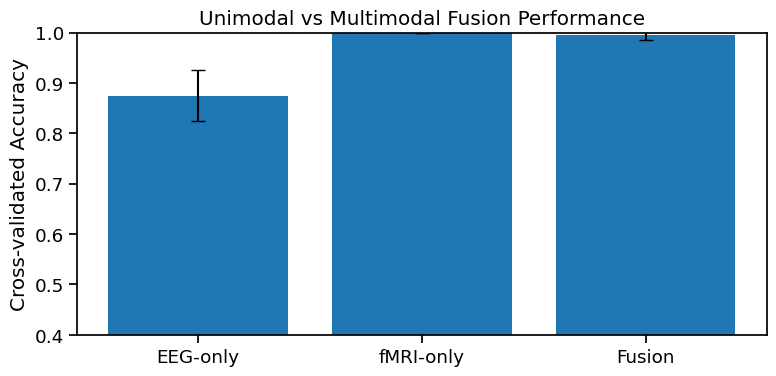

In [7]:
results = pd.DataFrame({
    'Model': ['EEG-only', 'fMRI-only', 'Fusion'],
    'Mean Accuracy': [scores_eeg.mean(), scores_fmri.mean(), scores_fused.mean()],
    'Std': [scores_eeg.std(), scores_fmri.std(), scores_fused.std()]
})
display(results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results['Model'], results['Mean Accuracy'], yerr=results['Std'], capsize=5)
ax.set_ylim(0.4, 1.0)
ax.set_ylabel('Cross-validated Accuracy')
ax.set_title('Unimodal vs Multimodal Fusion Performance')
plt.tight_layout()
plt.show()

## 6. Train Final Fusion Model & Inspect Confusion Matrix

Confusion matrix (train-on-all, for inspection):
[[100   0]
 [  0 100]]

Classification report:
              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00       100
     class 1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



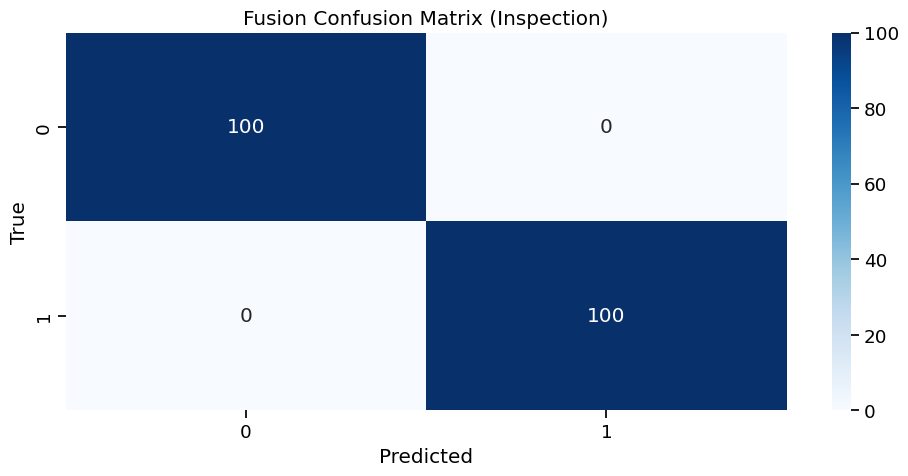

In [8]:
# Fit final model on full fused data (for didactic inspection only)
final_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='liblinear', random_state=42)
)
final_clf.fit(X_fused, y_pair)
y_pred = final_clf.predict(X_fused)

cm = confusion_matrix(y_pair, y_pred)
print("Confusion matrix (train-on-all, for inspection):")
print(cm)

print("\nClassification report:")
print(classification_report(y_pair, y_pred, target_names=['class 0', 'class 1']))

fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Fusion Confusion Matrix (Inspection)')
plt.tight_layout()
plt.show()

## 7. Interpretation and Next Steps

If fusion outperforms both unimodal models, it suggests the modalities carry **complementary information**.

To move toward research-grade EEG-fMRI fusion:
- Add explicit **co-registration** steps (EEG digitization/fiducials -> MRI -> MNI/source space)
- Use truly aligned simultaneous EEG-fMRI datasets (same subjects/trials)
- Add robust run/subject grouping in CV (`GroupKFold`, `LeaveOneGroupOut`)
- Compare multiple fusion strategies:
  - early fusion (feature concatenation)
  - late fusion (ensemble of unimodal classifiers)
  - deep multimodal networks (two encoders + fusion head)
- Add permutation testing from 7.3 to validate significance of fusion gains

This notebook provides a practical baseline architecture for multimodal feature fusion in this repository.